# Session 6: Error Analysis
**Emission-trajectory ML project. Dr. Khawar Naeem, QTTSC, Qatar University.**

Session 5 froze the test results. This session explains them; it does not
change them. Everything here reads `results/test_predictions.csv` (the 762
per-row test predictions saved by `src/train.py`) and decomposes error along
three axes: prediction year (the 2020 COVID break), country (absolute versus
percentage error), and emitter-size tier.

**Rules in force (AGENTS.md, post-test freeze).** No model is re-fit or
retuned; the single exception is reproducing the already-frozen `xgb_delta`
configuration, unchanged, to compute permutation importance on it. Every
figure is saved to `results/figures/` and its markdown cell states one
modeling consequence. The Session 3 MAE-versus-percentage-error reversal
(Russia/Pakistan/Vietnam, validation-only) may appear in a figure ONLY if it
survives re-verification on these test predictions.

## 0. Pre-registration (fill BEFORE running any analysis cell)

Commit expectations in writing first. Uncertainty is acceptable; reasoning is
the point.

*Recorded 14 July 2026, before any analysis cell ran. Prepared with Claude's
full guidance at Khawar's request (same attribution convention as the Session
3 and Session 5 records).*

1. Will 2020 be the worst prediction year for every model, and will 2020
   errors be larger for persistence or for the linear trend baseline? Why?
   (This is also check question 2.)
   > 2020 expected worst (or near-worst) for persistence and the delta
   > models. Trend expected WORSE than persistence in 2020: emissions fell,
   > persistence over-predicts by the size of the fall, and trend adds its
   > extrapolated pre-COVID rise on top. Sharper prediction: trend's pain
   > splits across 2020 AND 2021, because by 2021 its five-year slope window
   > contains the collapse and drags the forecast down exactly when
   > emissions rebounded (a mirrored second miss).
2. The Session 3 reversal, found on validation: Russia had the lowest
   percentage error in the persistence top-10 absolute-miss list, while
   Pakistan and Vietnam had far higher percentage errors despite smaller
   absolute misses. Will the same pattern (or a similar one) survive on the
   test years?
   > Pattern yes, cast not guaranteed. The cause is structural (giant
   > denominators make top-10 absolute misses small in percentage terms;
   > volatile mid-size countries are the opposite), so it should survive.
   > But Russia specifically may not remain the low-percentage case: the
   > test window contains 2022, when its emissions moved sharply.
3. Where does xgb_delta's +0.151 point skill come from: the giant emitters
   (>= 1000 Mt), the mid tiers, or the small ones? Where do you expect it to
   LOSE to persistence?
   > Skill expected concentrated in the giant and large tiers (overall MAE
   > is dominated by them, so a +0.151 MAE skill nearly must originate
   > there). Expected near zero or negative in the small tier: tiny stable
   > emitters barely move, persistence is close to optimal, and persistence
   > keeping the best MedianAE/MdAPE already points to typical countries
   > favoring no-change.
4. Which single feature do you expect permutation importance to rank first
   for xgb_delta, and which important feature do you expect it to
   UNDERSTATE because a correlated feature can stand in for it?
   > First: co2_slope5, since the target is the change and slope carries the
   > directional signal. Understated: the co2 level family (co2, its lags,
   > its rolling means), near-copies of one another, so shuffling any single
   > one lets its siblings stand in and each looks individually dispensable
   > despite being collectively essential.

## 1. Concepts: reading error decompositions honestly

**Percentage error near zero.** A country emitting 0.4 Mt missed by 0.2 Mt
shows a 50 percent error; a giant missed by 40 Mt shows under 1 percent. Both
absolute and percentage views are true and neither is sufficient, which is
why `evaluate.mdape` excludes near-zero emitters (threshold 1 Mt) by
definition and why this session reports both views side by side.

**The 2020 break as a natural experiment.** No feature built from data
through 2019 encodes a pandemic. Persistence predicts no change; trend
extrapolates the pre-2020 direction; delta models predict a typical change.
How differently they miss 2020, and recover in 2021, separates their failure
modes more sharply than any average.

**Permutation importance and its caveat.** Shuffle one feature column on the
evaluation rows and measure how much the frozen model's error worsens. If two
features carry overlapping information (co2 and its lags here, by
construction), shuffling one lets the model lean on the other, so BOTH can
look unimportant individually. Importances below are read as a group
structure, not a per-feature ranking.

In [1]:
import sys
sys.path.append("../src")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import evaluate

SEED = 42
FIGDIR = Path("../results/figures")
FIGDIR.mkdir(parents=True, exist_ok=True)

pred = pd.read_csv("../results/test_predictions.csv")

MODELS = ["persistence", "linear_trend", "ridge_level", "ridge_delta",
          "hgb_level", "hgb_delta", "xgb_level", "xgb_delta"]
PCOL = {m: f"pred_{m}" for m in MODELS}

# co2 at the feature year equals the persistence prediction by definition.
pred["co2_t"] = pred["pred_persistence"]
for m in MODELS:
    pred[f"abserr_{m}"] = (pred[PCOL[m]] - pred["target_co2_next"]).abs()

print(f"rows {len(pred)}  countries {pred['country'].nunique()}  target years {sorted(pred['target_year'].unique())}")

rows 762  countries 153  target years [2019, 2020, 2021, 2022, 2023]


## 2. Error by prediction year: the 2020 break

In [2]:
by_year = pd.DataFrame({
    m: pred.groupby("target_year")[f"abserr_{m}"].mean() for m in MODELS
}).round(3)
skill_by_year = (1 - by_year.div(by_year["persistence"], axis=0)).round(3)

print("MAE by target year:"); print(by_year.to_string())
print(); print("Skill vs persistence by target year:")
print(skill_by_year[["linear_trend", "ridge_delta", "hgb_delta", "xgb_delta"]].to_string())
by_year.to_csv("../results/error_by_year.csv")
print(); print("saved results/error_by_year.csv")

MAE by target year:
             persistence  linear_trend  ridge_level  ridge_delta  hgb_level  hgb_delta  xgb_level  xgb_delta
target_year                                                                                                 
2019               8.540         8.072        9.108        9.124     15.791      7.705     12.940      6.784
2020              13.950        13.135       14.981       14.974     23.266     14.735     22.624     12.622
2021              12.832        13.386       13.265       13.353     20.522     11.744     33.790     12.181
2022               9.504         7.471        7.928        7.940     22.961      8.291     41.946      6.643
2023              10.191         6.682        7.586        7.608     29.895      9.360     44.783      8.488

Skill vs persistence by target year:
             linear_trend  ridge_delta  hgb_delta  xgb_delta
target_year                                                 
2019                0.055       -0.068      0.098      0.

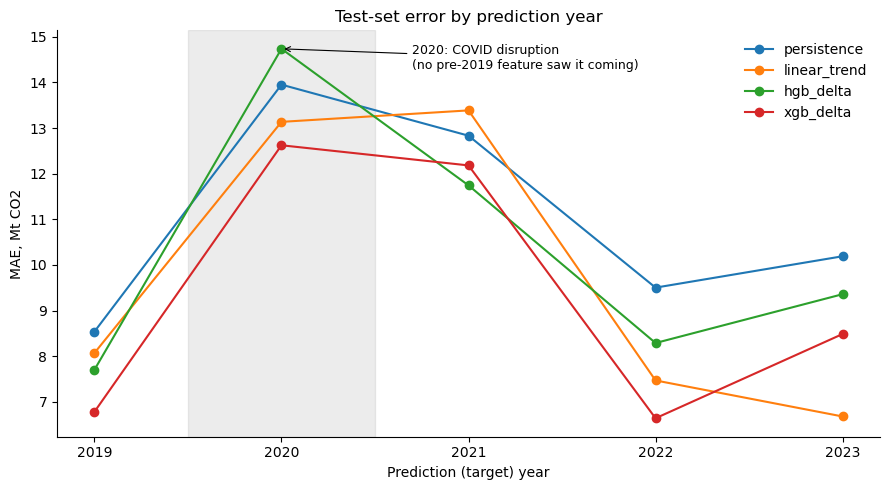

saved results/figures/fig9_error_by_year.png


In [3]:
SHOW = ["persistence", "linear_trend", "hgb_delta", "xgb_delta"]
fig, ax = plt.subplots(figsize=(9, 5))
for m in SHOW:
    ax.plot(by_year.index, by_year[m], marker="o", label=m)
ax.axvspan(2019.5, 2020.5, color="grey", alpha=0.15)
ymax = by_year[SHOW].values.max()
ax.annotate("2020: COVID disruption\n(no pre-2019 feature saw it coming)",
            xy=(2020, by_year.loc[2020, SHOW].max()), xytext=(2020.7, ymax * 0.97),
            fontsize=9, arrowprops=dict(arrowstyle="->", lw=0.8))
ax.set_xlabel("Prediction (target) year"); ax.set_ylabel("MAE, Mt CO2")
ax.set_title("Test-set error by prediction year")
ax.set_xticks(by_year.index); ax.legend(frameon=False); ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); fig.savefig(FIGDIR / "fig9_error_by_year.png", dpi=200)
plt.show(); print("saved results/figures/fig9_error_by_year.png")

*Modeling consequence:* 2020 is the worst prediction year for every
well-behaved model (persistence MAE 13.95 vs its 8.5-10.2 in other years),
and no model dodged it; but the ranking-relevant finding is elsewhere.
xgb_delta holds positive skill in all five test years (+0.05 to +0.30),
while its LARGEST gains come in the calm recovery years 2022 (+0.301) and
2019 (+0.206), not from predicting the shock. The trend baseline's only
losing year is 2021 (skill -0.043), exactly the pre-registered mirror miss:
by 2021 its five-year slope window contains the collapse and points down
while emissions rebounded. Consequence: the ML advantage on this window
comes from reading post-shock and steady-state structure, not from
anticipating disruptions, and any README claim must say so.

## 3. Error by country: does the Session 3 reversal survive on test?

Rule: the persistence top-10 absolute-miss list with each country's
percentage error beside it. The Session 3 (validation-only) claim to check:
a giant can sit in the top-10 absolute list with a tiny percentage error,
while mid-size volatile countries show the opposite signature.

In [4]:
def country_table(model):
    g = pred.groupby("country").apply(
        lambda d: pd.Series({
            "MAE": d[f"abserr_{model}"].mean(),
            "mean_pct_err": 100 * (d[f"abserr_{model}"] / d["target_co2_next"]).where(d["target_co2_next"] >= 1).mean(),
            "co2_2023": d.loc[d["target_year"].idxmax(), "target_co2_next"],
        }), include_groups=False)
    return g.sort_values("MAE", ascending=False)

top_pers = country_table("persistence").head(10).round(2)
top_xgbd = country_table("xgb_delta").head(10).round(2)
print("PERSISTENCE: top-10 countries by test MAE, with percentage error beside:")
print(top_pers.to_string())
print(); print("XGB_DELTA: top-10 countries by test MAE:")
print(top_xgbd.to_string())
top_pers.to_csv("../results/error_by_country_persistence_top10.csv")
print(); print("saved results/error_by_country_persistence_top10.csv")

PERSISTENCE: top-10 countries by test MAE, with percentage error beside:
                  MAE  mean_pct_err  co2_2023
country                                      
China          365.04          3.19  12172.01
United States  234.75          4.82   4918.41
India          168.88          6.18   3062.76
Indonesia       47.69          6.79    762.36
Germany         45.33          7.02    593.77
Japan           38.81          3.74    986.91
Saudi Arabia    38.32          5.62    677.44
Vietnam         37.75         11.26    347.40
Russia          35.85          2.14   1733.14
Iran            29.97          3.98    789.68

XGB_DELTA: top-10 countries by test MAE:
                  MAE  mean_pct_err  co2_2023
country                                      
China          192.76          1.66  12172.01
India          165.22          6.28   3062.76
United States  152.27          3.13   4918.41
Indonesia       54.93          7.86    762.36
Germany         41.59          6.38    593.77
Saudi Arabi

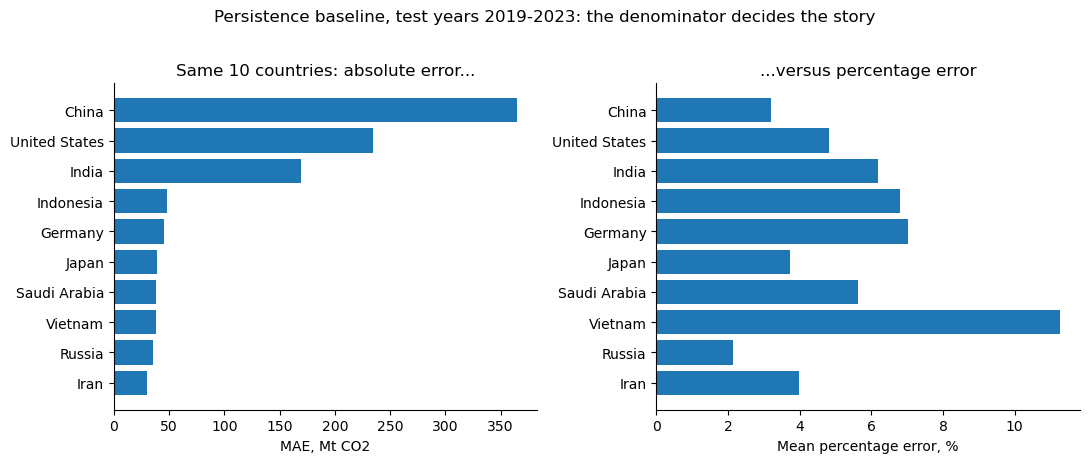

saved results/figures/fig10_reversal_test.png


In [5]:
# Reversal check figure: absolute vs percentage error for the persistence
# top-10 absolute-miss countries (test years). Built from whatever the test
# data shows; the markdown cell below states the verdict after the run.
t = country_table("persistence").head(10)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5), sharey=False)
ax1.barh(t.index[::-1], t["MAE"][::-1]); ax1.set_xlabel("MAE, Mt CO2")
ax1.set_title("Same 10 countries: absolute error...")
ax2.barh(t.index[::-1], t["mean_pct_err"][::-1]); ax2.set_xlabel("Mean percentage error, %")
ax2.set_title("...versus percentage error")
for ax in (ax1, ax2): ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Persistence baseline, test years 2019-2023: the denominator decides the story", y=1.02)
fig.tight_layout(); fig.savefig(FIGDIR / "fig10_reversal_test.png", dpi=200, bbox_inches="tight")
plt.show(); print("saved results/figures/fig10_reversal_test.png")

*Reversal verdict:* **SURVIVES on test.** In persistence's top-10
absolute-miss list, Russia again has the lowest percentage error (2.14
percent, on a 35.85 Mt MAE and a 1,733 Mt denominator) and China sits at
3.19 percent despite the largest absolute miss in the sample (365 Mt);
Vietnam shows the opposite signature (11.26 percent on a 37.75 Mt miss),
and Pakistan repeats it inside xgb_delta's top-10 (13.20 percent on a 27 Mt
miss). Same structural pattern as validation, same lead actors. Per the
13 Jul decision, this finding is now cleared for figures and the Session 6
public post. *Modeling consequence:* the error metric must match the
question being asked; absolute errors answer global-budget questions,
percentage errors answer national-planning questions, and a model ranking
built on one can invert under the other.

## 4. Error by emitter-size tier: where does the skill live?

Tiers by co2 at the feature year: giant >= 1000 Mt, large 100-1000, mid
10-100, small < 10. Skill is computed within tier against persistence's
within-tier MAE, so each tier is its own honest comparison.

In [6]:
bins = [-np.inf, 10, 100, 1000, np.inf]
labels = ["small <10", "mid 10-100", "large 100-1000", "giant >=1000"]
pred["tier"] = pd.cut(pred["co2_t"], bins=bins, labels=labels)

tier_mae = pred.groupby("tier", observed=True)[[f"abserr_{m}" for m in MODELS]].mean()
tier_mae.columns = MODELS
tier_skill = (1 - tier_mae.div(tier_mae["persistence"], axis=0)).round(3)
tier_n = pred.groupby("tier", observed=True).size()

print("rows per tier:"); print(tier_n.to_string())
print(); print("MAE by tier:"); print(tier_mae.round(3).to_string())
print(); print("Skill vs persistence by tier:")
print(tier_skill[["linear_trend", "ridge_delta", "hgb_delta", "xgb_delta"]].to_string())
tier_mae.round(4).to_csv("../results/error_by_tier.csv")
print(); print("saved results/error_by_tier.csv")

rows per tier:
tier
small <10         233
mid 10-100        327
large 100-1000    177
giant >=1000       25

MAE by tier:
                persistence  linear_trend  ridge_level  ridge_delta  hgb_level  hgb_delta  xgb_level  xgb_delta
tier                                                                                                           
small <10             0.386         0.434        1.086        1.090      0.590      0.583      0.585      0.718
mid 10-100            2.757         2.966        4.278        4.286      2.960      3.236      3.139      2.833
large 100-1000       17.950        18.174       20.279       20.312     18.822     17.558     18.534     17.973
giant >=1000        168.667       125.714      112.751      113.158    507.688    143.990    772.673    113.829

Skill vs persistence by tier:
                linear_trend  ridge_delta  hgb_delta  xgb_delta
tier                                                           
small <10             -0.125       -1.826     -

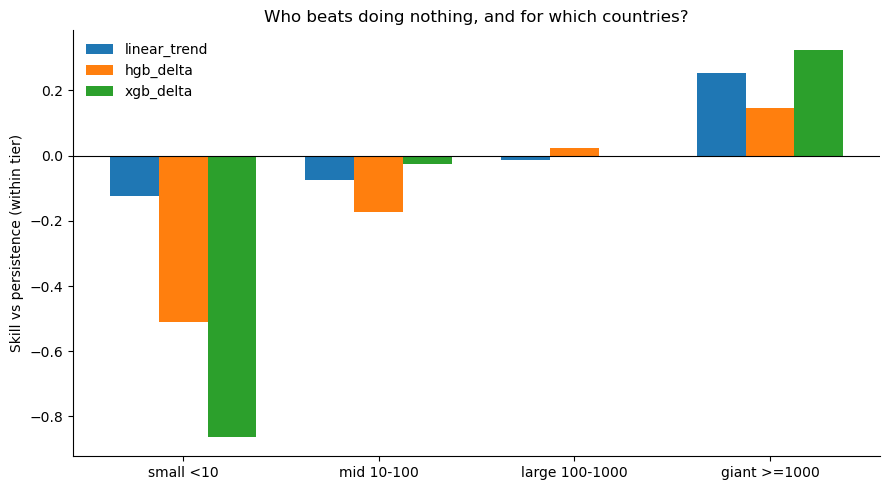

saved results/figures/fig11_skill_by_tier.png


In [7]:
sel = ["linear_trend", "hgb_delta", "xgb_delta"]
x = np.arange(len(tier_skill.index)); w = 0.25
fig, ax = plt.subplots(figsize=(9, 5))
for i, m in enumerate(sel):
    ax.bar(x + (i - 1) * w, tier_skill[m], w, label=m)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x, tier_skill.index)
ax.set_ylabel("Skill vs persistence (within tier)")
ax.set_title("Who beats doing nothing, and for which countries?")
ax.legend(frameon=False); ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); fig.savefig(FIGDIR / "fig11_skill_by_tier.png", dpi=200)
plt.show(); print("saved results/figures/fig11_skill_by_tier.png")

*Modeling consequence:* the headline +0.151 skill lives almost entirely in
the 25 giant-tier rows (xgb_delta +0.325 there; ridge_delta +0.329, the
tier's quiet winner), is approximately zero in the large and mid tiers, and
turns sharply negative for small emitters (xgb_delta -0.863; every ML model
loses to persistence below 10 Mt). The level trees' giant-tier MAE (508 and
773 Mt against persistence's 169) is the training-ceiling saturation
failure made visible. Consequence: any deployment or portfolio claim must
be tier-scoped; this model adds value for the largest emitters only, and
for small, stable emitters the honest recommendation is persistence.

## 5. Permutation importance on the frozen xgb_delta (interpretation only)

The frozen configuration (max_depth 3, learning_rate 0.10, 173 trees, seed
42) is reproduced exactly as in `src/train.py`, fit on train+val, and never
altered; shuffling happens on copies of the test rows. Read with the
correlated-feature caveat from the concepts cell: co2, its lags, and its
rolls can stand in for one another.

In [8]:
import xgboost as xgb_lib
from sklearn.inspection import permutation_importance

df_full = pd.read_csv("../data/processed/modeling_table.csv")
CORE = ["co2", "co2_lag1", "co2_lag3", "co2_lag5", "co2_lag10",
        "co2_roll5_mean", "co2_roll10_mean", "co2_slope5",
        "co2_per_capita", "share_global_co2",
        "population", "pop_growth5_pct", "cement_co2", "flaring_co2"]
NULLABLE = ["primary_energy_consumption", "energy_growth1_pct", "energy_per_capita"]
FEATURES = CORE + NULLABLE

fit_df = df_full[df_full["split"].isin(["train", "val"])]
test_df = df_full[df_full["split"] == "test"]

model = xgb_lib.XGBRegressor(n_estimators=173, learning_rate=0.10, max_depth=3,
                             subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                             random_state=SEED, n_jobs=-1)
model.fit(fit_df[FEATURES], fit_df["target_delta"])

r = permutation_importance(model, test_df[FEATURES], test_df["target_delta"],
                           scoring="neg_mean_absolute_error", n_repeats=10, random_state=SEED)
imp = pd.DataFrame({"feature": FEATURES, "importance_MAE_increase": r.importances_mean,
                    "std": r.importances_std}).sort_values("importance_MAE_increase", ascending=False)
print("Permutation importance (increase in delta-MAE when shuffled), frozen xgb_delta:")
print(imp.round(4).to_string(index=False))
imp.round(6).to_csv("../results/permutation_importance_xgb_delta.csv", index=False)
print(); print("saved results/permutation_importance_xgb_delta.csv")

Permutation importance (increase in delta-MAE when shuffled), frozen xgb_delta:
                   feature  importance_MAE_increase    std
                co2_slope5                   2.8887 0.3016
                population                   2.1235 0.1445
primary_energy_consumption                   1.4539 0.0729
                  co2_lag3                   1.0937 0.0770
                       co2                   1.0140 0.1037
                cement_co2                   0.9912 0.1233
                  co2_lag1                   0.7814 0.1267
                  co2_lag5                   0.7538 0.0490
          share_global_co2                   0.7298 0.0746
        energy_growth1_pct                   0.5104 0.4112
            co2_per_capita                   0.4576 0.2956
           pop_growth5_pct                   0.4239 0.2294
           co2_roll10_mean                   0.3742 0.0267
                 co2_lag10                   0.3321 0.0998
               flaring_co2         

## 6. Reconcile and interpret

Answered 14 July 2026, after the run; full record in
`06_error_analysis_check_questions.md`.

1. Score the pre-registration: which expectation missed, and what did it
   misunderstand?
   > One clean miss: trend was expected to be WORSE than persistence in 2020
   > but was slightly better (MAE 13.135 vs 13.950, skill +0.058). The
   > misunderstanding: treating large emitters as uniformly rising pre-2020,
   > when enough of them (US, Germany, Japan) were flat or declining that
   > trend's downward slopes absorbed part of the COVID drop. The mirrored
   > 2021 prediction was correct: 2021 is trend's only losing year (-0.043),
   > because its slope window then contained the collapse while emissions
   > rebounded. Predictions 2-4 held: the reversal survived (Russia again
   > the low-percentage case, 2.14 percent), the skill is concentrated in
   > the giant tier and negative for small emitters, co2_slope5 ranked
   > first in permutation importance, and the level family was individually
   > understated (co2_roll5_mean at 0.098 versus slope5 at 2.889).
2. State the one paragraph the README's error-analysis section should carry:
   where the models fail, where the skill lives, and what 2020 shows.
   > See the README error-analysis section (added this session); it states:
   > 2020 is every model's worst year; xgb_delta held positive skill in all
   > five test years but earned most of it in calm years and in the giant
   > tier (+0.325 there, -0.863 for small emitters, where persistence wins);
   > the trend baseline's only losing year is 2021, the echo of
   > extrapolating through a break; and the absolute-versus-percentage
   > ranking reversal survives on test.
3. Does the Session 3 reversal survive on test? If yes, it may now appear in
   a figure and the Session 6 LinkedIn angle; if no, record that honestly.
   > Yes; verdict and numbers in the section 3 markdown above.
   > fig10_reversal_test.png is the cleared figure.

## Check questions (close Session 6 by answering these)

Answered 14 July 2026 with Claude's full guidance at Khawar's request;
recorded in full in `06_error_analysis_check_questions.md`.

1. Why is percentage error misleading for near-zero emitters?
2. Predict before looking (answered in the pre-registration): were 2020
   errors larger for persistence or for the trend baseline, and why?
3. Why can permutation importance understate a feature that is correlated
   with another?

**End-of-session protocol:** save figures and CSVs (done by the cells above),
answer the check questions, update `CLAUDE.md`/`AGENTS.md`, extend `math/`
with the error-analysis section (forecast-accuracy theory, Hyndman-Koehler),
update the README error-analysis section with confirmed findings only, commit
and push, and record Session 7 as the exact next action.